# Student Dropout & Academic Success — Model Training

Trains and evaluates 5 classifiers (Logistic Regression, Decision Tree, kNN, Gaussian Naive Bayes, Random Forest) on the UCI ["Predict Students' Dropout and Academic Success"](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset, and saves the fitted pipelines, benchmark metrics, and held-out test split used by the Streamlit app.

**Problem**: predict whether a student will drop out, stay enrolled, or graduate, from data known at enrollment plus first/second-semester academic performance. This is a 3-class classification problem (`Dropout` / `Enrolled` / `Graduate`).

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append(str(Path.cwd()))
from preprocessing import TARGET_COLUMN, CLASS_NAMES, get_feature_columns, build_pipeline
from metrics_utils import compute_metrics

sns.set_theme(style="whitegrid")
REPO_ROOT = Path.cwd().parent
SAVE_DIR = Path.cwd() / "saved"
SAVE_DIR.mkdir(exist_ok=True)

## 1. Load data and a quick look at class balance

In [2]:
df = pd.read_csv(REPO_ROOT / "data" / "dataset.csv")
feature_cols = get_feature_columns(df)
print(f"{df.shape[0]} rows, {len(feature_cols)} features, target = {TARGET_COLUMN!r}")
df[TARGET_COLUMN].value_counts()

4424 rows, 36 features, target = 'Target'


Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

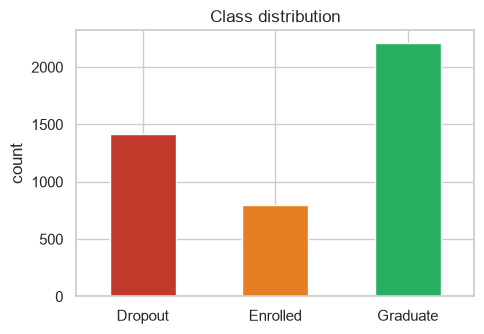

In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
df[TARGET_COLUMN].value_counts().loc[CLASS_NAMES].plot(kind="bar", color=["#c0392b", "#e67e22", "#27ae60"], ax=ax)
ax.set_title("Class distribution")
ax.set_xlabel("")
ax.set_ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Train/test split

All 5 models are trained on the same stratified 80/20 split so the comparison table is fair. The test split (`X_test`/`y_test`) is exported to `test_data.csv` at the end of this notebook once every model has been evaluated against it.

Every feature in this dataset is numeric (either continuous, e.g. grades, or already integer-coded, e.g. `Course`, `Application mode`) and there are no missing values, so no imputation or categorical encoding is needed before training.

In [4]:
X = df[feature_cols]
y = df[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"train: {X_train.shape[0]} rows, test: {X_test.shape[0]} rows")

results = {}  # model_key -> metrics dict, filled in as each model below is trained

train: 3539 rows, test: 885 rows


In [5]:
def train_and_save(model_key: str, display_name: str, classifier):
    """Fit `classifier` inside a Pipeline, evaluate on the shared test split, save the pipeline."""
    pipeline = build_pipeline(model_key, classifier)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)
    metrics = compute_metrics(y_test, y_pred, y_proba)
    results[model_key] = {"display_name": display_name, **metrics}

    joblib.dump(pipeline, SAVE_DIR / f"{model_key}.joblib")
    print(display_name)
    for k, v in metrics.items():
        print(f"  {k:10s} {v:.4f}")
    return pipeline

## 3. Logistic Regression

Linear baseline. Scaled (see `SCALED_MODELS` in `preprocessing.py`) since it's a gradient-based, distance-sensitive model.

In [6]:
from sklearn.linear_model import LogisticRegression

_ = train_and_save(
    "logistic_regression",
    "Logistic Regression",
    LogisticRegression(max_iter=2000, random_state=42),
)

Logistic Regression
  accuracy   0.7684
  auc        0.8778
  precision  0.7070
  recall     0.6754
  f1         0.6826
  mcc        0.6150


## 4. Decision Tree

`max_depth=8` caps tree growth to keep it from memorizing the training set — a fully-grown tree on 36 features tends to overfit badly on a dataset this size.

In [7]:
from sklearn.tree import DecisionTreeClassifier

_ = train_and_save(
    "decision_tree",
    "Decision Tree",
    DecisionTreeClassifier(max_depth=8, random_state=42),
)

Decision Tree
  accuracy   0.7288
  auc        0.8125
  precision  0.6735
  recall     0.6583
  f1         0.6636
  mcc        0.5542


## 5. K-Nearest Neighbors

Swept odd `k` from 5 to 25 (scaled features, test accuracy as the selection criterion): accuracy climbs from 0.668 at k=5 to a peak of 0.715 at k=21, then flattens. Using `k=21`.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

_ = train_and_save(
    "knn",
    "K-Nearest Neighbors",
    KNeighborsClassifier(n_neighbors=21),
)

K-Nearest Neighbors
  accuracy   0.7153
  auc        0.8285
  precision  0.6794
  recall     0.5941
  f1         0.6016
  mcc        0.5273
